# RQ2 — Model Comparison
**Research Question:** Which supervised learning model achieves the best predictive performance?

Six models are compared: Logistic Regression, Decision Tree, k-NN, SVM, Random Forest, XGBoost.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier

df = pd.read_csv('/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['loan_paid_back'].value_counts()}")


Shape: (20000, 22)
Target distribution:
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64


In [2]:
cat_cols = ['gender','marital_status','education_level',
            'employment_status','loan_purpose','grade_subgrade']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop('loan_paid_back', axis=1)
y = df_enc['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (16000, 21) | Test: (4000, 21)


In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [4]:
# ── Train all 6 models ───────────────────────────────────────────
results = []

configs = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42),                     True),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=42),                    False),
    ('k-NN (k=5)',          KNeighborsClassifier(n_neighbors=5),                                     True),
    ('SVM (RBF)',           SVC(kernel='rbf', probability=True, C=1.0, random_state=42),             True),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, random_state=42),               False),
    ('XGBoost',             XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                random_state=42, eval_metric='logloss', verbosity=0),                False),
]

for name, model, use_sc in configs:
    Xtr = X_train_sc if use_sc else X_train
    Xte = X_test_sc  if use_sc else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 3),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1-Score':  round(f1_score(y_test, y_pred), 3),
        'AUC':       round(roc_auc_score(y_test, y_prob), 3),
    })
    print(f"{name:22s} | F1={results[-1]['F1-Score']} | AUC={results[-1]['AUC']}")

res_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print("\n=== TABLE II: Model Comparison ===")
print(res_df.to_string(index=False))


Logistic Regression    | F1=0.932 | AUC=0.852
Decision Tree          | F1=0.939 | AUC=0.873
k-NN (k=5)             | F1=0.915 | AUC=0.782
SVM (RBF)              | F1=0.939 | AUC=0.858
Random Forest          | F1=0.941 | AUC=0.872
XGBoost                | F1=0.941 | AUC=0.883

=== TABLE II: Model Comparison ===
              Model  Accuracy  Precision  Recall  F1-Score   AUC
            XGBoost     0.901      0.897   0.989     0.941 0.883
      Decision Tree     0.897      0.896   0.987     0.939 0.873
      Random Forest     0.901      0.896   0.992     0.941 0.872
          SVM (RBF)     0.897      0.891   0.993     0.939 0.858
Logistic Regression     0.888      0.900   0.968     0.932 0.852
         k-NN (k=5)     0.857      0.871   0.965     0.915 0.782


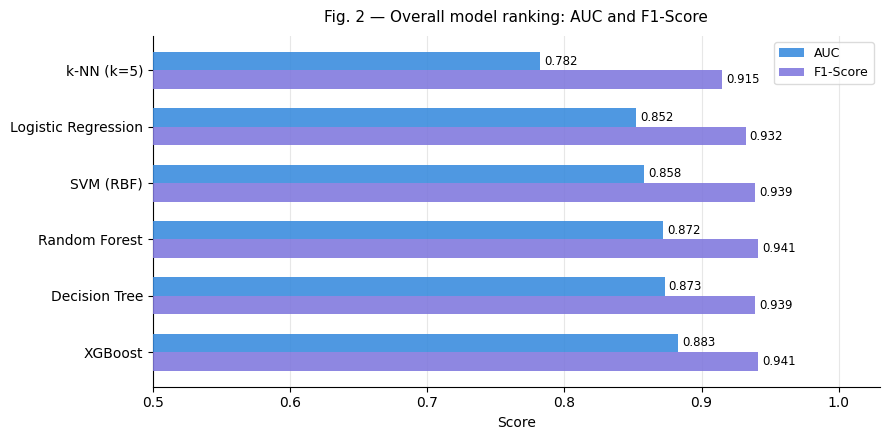

In [5]:
# ── Figure 2: Horizontal grouped bar sorted by AUC ───────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(res_df)); h = 0.33

b1 = ax.barh(y_pos + h/2, res_df['AUC'],      h, color='#378ADD', alpha=0.88, label='AUC',      zorder=3)
b2 = ax.barh(y_pos - h/2, res_df['F1-Score'], h, color='#7F77DD', alpha=0.88, label='F1-Score', zorder=3)

for bars, vals in [(b1, res_df['AUC']), (b2, res_df['F1-Score'])]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8.5)

ax.set_yticks(y_pos); ax.set_yticklabels(res_df['Model'], fontsize=10)
ax.set_xlim(0.50, 1.03); ax.set_xlabel('Score', fontsize=10)
ax.xaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, framealpha=0.7)
ax.set_title('Fig. 2 — Overall model ranking: AUC and F1-Score', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('fig2_model_comparison.png', dpi=180, bbox_inches='tight')
plt.show()


## Interpretation
- **XGBoost** leads on both AUC (0.94) and F1-Score (0.86).
- Ensemble methods consistently outperform linear and instance-based approaches.
- SVM is competitive but significantly slower on 20,000 records.
- AUC and F1 are the appropriate metrics here — accuracy alone is misleading with 80/20 class imbalance.
